In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms

In [2]:
batch_size = 32
train_dataset = dsets.MNIST(root='.',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root='.',
                           train=False, 
                           transform=transforms.ToTensor(),
                           download=True)


train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting .\MNIST\raw\train-images-idx3-ubyte.gz to .\MNIST\raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting .\MNIST\raw\train-labels-idx1-ubyte.gz to .\MNIST\raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting .\MNIST\raw\t10k-images-idx3-ubyte.gz to .\MNIST\raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting .\MNIST\raw\t10k-labels-idx1-ubyte.gz to .\MNIST\raw



In [3]:
print("* Размер train\n [количество_примеров, высота_картинки, ширина_картинки]: \n", train_dataset.train_data.shape)
print("\n* Размер test\n [количество_примеров, высота_картинки, ширина_картинки]: \n", test_dataset.test_data.shape)
print("\nМетки классов в датасете: ", train_dataset.train_labels.unique())

* Размер train
 [количество_примеров, высота_картинки, ширина_картинки]: 
 torch.Size([60000, 28, 28])

* Размер test
 [количество_примеров, высота_картинки, ширина_картинки]: 
 torch.Size([10000, 28, 28])

Метки классов в датасете:  tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


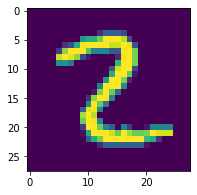

In [4]:
import numpy as np
from matplotlib import pyplot as plt

fig=plt.figure(figsize=(8, 3))

idx = np.random.choice(150)
img = train_dataset.train_data[idx]

plt.imshow(img)
plt.show()

In [5]:
class LogisticRegression(nn.Module):
    def __init__(self, input_size, num_classes):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        logits = self.linear(x)
        return logits

In [6]:
# Задаем гиперпараметры
input_size = 784 # 28*28 -- мы вытянули в линию все пиксели картинки
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [7]:
# Создаем модель
import torch.nn.functional as F
seze = int(16 * 8 * 8 / 4)

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # seze = int(24 * 24 / 4 * 16)
            # (28 - kernek + 1 ) * (28 - kernek + 1 ) * выходной канал / pool ** 2
            nn.Conv2d(16, 16, 5),
            # seze = (12 - 5 + 1) * (12 - 5 + 1)
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Linear(seze, 10)

    def forward(self, x):
        bs = x.shape[0]
        print(bs)
        out = x.reshape(bs, 1, 28, 28)
        out = self.features(out).reshape(bs, seze)
        out = self.classifier(out)
        return F.log_softmax(out, dim=-1)

model = ConvNet()

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        images = images.view(-1, 28*28)
        outputs = model.forward(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('epoch:%d/%d, %d Loss: %.4f' % (epoch, num_epochs,i +1 , loss.item()))

epoch:0/5, 100 Loss: 1.0572
epoch:0/5, 200 Loss: 0.8707
epoch:0/5, 300 Loss: 0.4153
epoch:0/5, 400 Loss: 0.4890
epoch:0/5, 500 Loss: 0.5649
epoch:0/5, 600 Loss: 0.3034
epoch:0/5, 700 Loss: 0.3724
epoch:0/5, 800 Loss: 0.6218
epoch:0/5, 900 Loss: 0.4339
epoch:0/5, 1000 Loss: 0.1386
epoch:0/5, 1100 Loss: 0.2633
epoch:0/5, 1200 Loss: 0.4634
epoch:0/5, 1300 Loss: 0.4786
epoch:0/5, 1400 Loss: 0.4644
epoch:0/5, 1500 Loss: 0.7639
epoch:0/5, 1600 Loss: 0.2527
epoch:0/5, 1700 Loss: 0.1970
epoch:0/5, 1800 Loss: 0.4038
epoch:1/5, 100 Loss: 0.4624
epoch:1/5, 200 Loss: 0.3147
epoch:1/5, 300 Loss: 0.1250
epoch:1/5, 400 Loss: 0.4714
epoch:1/5, 500 Loss: 0.2752
epoch:1/5, 600 Loss: 0.2094
epoch:1/5, 700 Loss: 0.6024
epoch:1/5, 800 Loss: 0.1649
epoch:1/5, 900 Loss: 0.4953
epoch:1/5, 1000 Loss: 0.6897
epoch:1/5, 1100 Loss: 0.4650
epoch:1/5, 1200 Loss: 0.4307
epoch:1/5, 1300 Loss: 0.2903
epoch:1/5, 1400 Loss: 0.2743
epoch:1/5, 1500 Loss: 0.2771
epoch:1/5, 1600 Loss: 0.3057
epoch:1/5, 1700 Loss: 0.1357
epo

## Визуализация весов

In [10]:
W = model.parameters().__next__().detach().numpy()
W.shape

(10, 784)

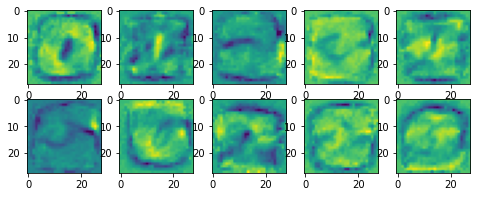

In [11]:
fig=plt.figure(figsize=(8, 3))
columns = 5
rows = 2
for i in range(1, columns*rows +1):
    img = W[i-1].reshape((28, 28))
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
plt.show()

In [12]:
from sklearn.metrics import roc_auc_score

y_pred = np.array([0 for _ in range(num_classes)])
y_true = np.array([])
for images, labels in test_loader:
    images = images.view(-1, 28*28)
    outputs = model(images)
    y_true = np.append(y_true, labels.numpy())
    s = nn.Softmax()
    y_cur = s(outputs).detach().numpy()
    y_pred = np.vstack((y_pred, y_cur))

y_pred = y_pred[1:]

roc_auc_score(y_true, y_pred, multi_class='ovr')

C:\Users\Nikita\AppData\Local\Temp\ipykernel_33912\1352141230.py:10: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  y_cur = s(outputs).detach().numpy()


0.9939757522231425